In [ ]:
import kagglehub


path = kagglehub.dataset_download("mujtabamatin/air-quality-and-pollution-assessment")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\DELL\.cache\kagglehub\datasets\mujtabamatin\air-quality-and-pollution-assessment\versions\2


In [ ]:
import pandas as pd
import numpy as np
dataset=pd.read_csv(r'Dataset.csv')

C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


The accuracy of the neural networks is: 0.936
The accuracy of the Decision tree is: 0.914
The accuracy of the naive base is: 0.921


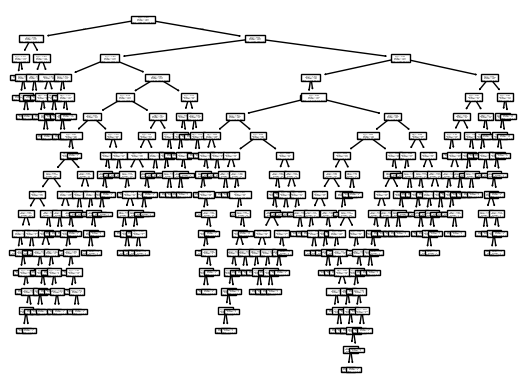

In [ ]:
numeric_columns = dataset.select_dtypes(include=np.number).columns
categorical_columns = dataset.select_dtypes(exclude=np.number).columns

from sklearn.impute import SimpleImputer
imp_mean = SimpleImputer(strategy='mean')
dataset[numeric_columns] = imp_mean.fit_transform(dataset[numeric_columns])

from sklearn.preprocessing import LabelEncoder
for col in categorical_columns:
    le = LabelEncoder()
    dataset[col] = le.fit_transform(dataset[col])


X = dataset.iloc[:, dataset.columns != 'Air Quality'].values
Y = dataset['Air Quality'].values


from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)


from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
x_train = sc_X.fit_transform(x_train)
x_test = sc_X.transform(x_test)

from sklearn import tree
DT=tree.DecisionTreeClassifier(criterion='entropy',random_state=0)
y_pred=DT.fit(x_train, y_train).predict(x_test)

from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(random_state=0, max_iter=50)
y_pred3=mlp.fit(x_train, y_train).predict(x_test)

from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(x_train, y_train)
y_pred2 = gnb.predict(x_test)

from sklearn.metrics import accuracy_score
tree_score=accuracy_score(y_pred, y_test)
nn_score=accuracy_score(y_pred3, y_test)
naive_acc=accuracy_score(y_pred2, y_test)

tree.plot_tree(DT)

print(f"The accuracy of the neural networks is: {nn_score}")
print(f"The accuracy of the Decision tree is: {tree_score}")
print(f"The accuracy of the naive base is: {naive_acc}") 